In [ ]:
'''
This script uses a lifecycle dataset of 1000 observations and 22 variables capturing carbon-related parameters across different
stages of a product’s lifecycle, including energy use, emissions, transport, usage conditions, and end-of-life characteristics.
From this data, total energy and emissions are estimated by combining production, usage, and energy system factors. It then compares
three strategies—repair, replace, and recycle—by assigning each a cost, energy, and environmental impact. These factors are normalized
and combined into a single score, and the option with the lowest score is selected.
'''

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# load data
df = pd.read_csv("product_lifecycle_carbon_dataset.csv")

# normalization
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

# --- energy ---
effective_manufacturing = df["manufacturing_energy"] / df["manufacturing_efficiency"]

usage_energy = df["usage_energy_consumption"] * df["usage_duration_hours"]

total_energy = (
    df["raw_material_energy"]
    + effective_manufacturing
    + df["logistics_energy"]
    + usage_energy
)

# --- emissions (separate energy and material) ---
energy_co2 = (
    (effective_manufacturing + df["logistics_energy"] + usage_energy)
    * df["grid_carbon_intensity"]
)

material_co2 = df["raw_material_energy"] * df["raw_material_emission_factor"]

co2 = energy_co2 + material_co2

# --- options ---
options = {
    "repair": {
        "co2": co2 * 0.2,
        "energy": total_energy * 0.3,
        "cost": 60,
        "value": 0
    },
    "replace": {
        "co2": co2,
        "energy": total_energy,
        "cost": 250,
        "value": 0
    },
    "recycle": {
        "co2": co2 * (1 - df["recycling_efficiency"]),
        "energy": effective_manufacturing * 0.3,
        "cost": 40,
        "value": normalize(df["recovered_material_value"])
    }
}

# --- normalize environmental factors ---
for opt in options:
    options[opt]["co2"] = normalize(options[opt]["co2"])
    options[opt]["energy"] = normalize(options[opt]["energy"])

# --- normalize costs ---
costs = [options[o]["cost"] for o in options]
cmin, cmax = min(costs), max(costs)

for opt in options:
    options[opt]["cost"] = (options[opt]["cost"] - cmin) / (cmax - cmin)

# --- scoring ---
def score(cost, co2, energy, value=0):
    return 0.3 * cost + 0.35 * co2 + 0.35 * energy - 0.3 * value

# --- compute scores ---
for opt in options:
    df[f"{opt}_score"] = score(
        options[opt]["cost"],
        options[opt]["co2"],
        options[opt]["energy"],
        options[opt]["value"]
    )

# --- best option ---
df["best_option"] = df[[f"{o}_score" for o in options]].idxmin(axis=1)

# --- results ---
print(df["best_option"].value_counts())

best_option
recycle_score    870
repair_score     130
Name: count, dtype: int64


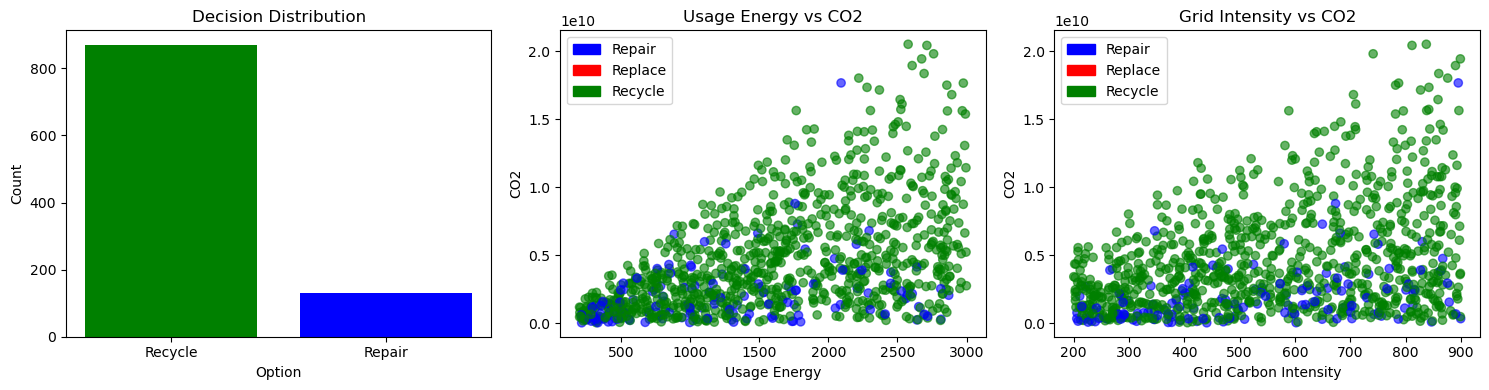

In [3]:
# consistent color map
color_map = {
    "Repair": "blue",
    "Replace": "red",
    "Recycle": "green"
}

# clean labels
df["best_option_clean"] = df["best_option"].replace({
    "repair_score": "Repair",
    "replace_score": "Replace",
    "recycle_score": "Recycle"
})

# map colors
colors = df["best_option_clean"].map(color_map)

# legend
legend_handles = [
    mpatches.Patch(color=color_map[k], label=k) for k in color_map
]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# --- 1. Decision distribution ---
counts = df["best_option_clean"].value_counts()

axs[0].bar(
    counts.index,
    counts.values,
    color=[color_map[k] for k in counts.index]
)

axs[0].set_title("Decision Distribution")
axs[0].set_xlabel("Option")
axs[0].set_ylabel("Count")

# --- 2. Usage energy vs CO2 ---
axs[1].scatter(
    df["usage_energy_consumption"], co2,
    c=colors, alpha=0.6
)
axs[1].set_title("Usage Energy vs CO2")
axs[1].set_xlabel("Usage Energy")
axs[1].set_ylabel("CO2")
axs[1].legend(handles=legend_handles)

# --- 3. Grid intensity vs CO2 ---
axs[2].scatter(
    df["grid_carbon_intensity"], co2,
    c=colors, alpha=0.6
)
axs[2].set_title("Grid Intensity vs CO2")
axs[2].set_xlabel("Grid Carbon Intensity")
axs[2].set_ylabel("CO2")
axs[2].legend(handles=legend_handles)

plt.tight_layout()
plt.show()

In [ ]:
'''
The figure shows how the preferred decision changes across different conditions. Based on this dataset and for this product,
recycling is the dominant option, while repair appears mainly in cases with lower usage energy and lower emissions.
As usage energy and carbon intensity increase, the model shifts toward recycling, indicating that recovering materials becomes
more favorable than extending the product’s life.
'''